## Atividade 01 (Individual)

**Não serão aceitas atividades iguais de dois alunos.**

Essa será a primeira atividade valendo nota na disciplina.

Os passos para essa atividade são:

1 - Faça uma cópia de arquivo para o seu google drive, renomeie o arquivo com o seguinte nome: "Atividade 01 - Seu Nome.ipynb", em que "Seu Nome" deve substituido pelo seu nome.

2 - Abra o arquivo no Colab.

3 - Rode todos os códigos abaixo no Colab.

4 - Responda todas as perguntas abaixo que são numeradas de 1 até 7.

5 - Imprima em PDF esse documento e entregue a atividade no Classroom.

Fonte da base de dados: [https://archive.ics.uci.edu/dataset/162/forest+fires](https://archive.ics.uci.edu/dataset/162/forest+fires)

Serão apresentadas análise de dados sobre incêndios florestais no noroeste de Portugal.

Tabela de features em inglês (Não deu tempo de traduzir)


Variable Name |	Role |	Type	| Description |	Units	| Missing Values
-|-|-|-|:-:|:-:
X	| Feature | Integer |	x-axis spatial coordinate within the Montesinho park map: 1 to 9  | |		no
Y	|	Feature	|	Integer	|	y-axis spatial coordinate within the Montesinho park map: 2 to 9	|	|		no
month	|	Feature	|	Categorical	|	month of the year: 'jan' to 'dec'	|	|		no
day	|	Feature	|	Categorical	|	day of the week: 'mon' to 'sun'	|	|		no
FFMC	|	Feature	|	Continuous	|	FFMC index from the FWI system: 18.7 to 96.20	|	|		no
DMC	|	Feature	|	Integer	|	DMC index from the FWI system: 1.1 to 291.3	|	|		no
DC	|	Feature	|	Continuous	|	DC index from the FWI system: 7.9 to 860.6	|	|		no
ISI	|	Feature	|	Continuous	|	ISI index from the FWI system: 0.0 to 56.10	|	|		no
temp	|	Feature	|	Continuous	|	temperature: 2.2 to 33.30	| Celsius degrees	|	no
RH	|	Feature	|	Integer	|	relative humidity: 15.0 to 100	|	%	|	no


### Importando as bibliotecas e importando a base de dados

In [2]:
import pandas as pd

import matplotlib.pyplot as plt


In [3]:
ff = pd.read_csv('https://raw.githubusercontent.com/OrlandoIFPR/ml2/main/Dataframes/Atividades/01-forestfires.csv')

In [4]:
ff.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


### 1 - O que o método `head()` faz e para o que serve?

---




---
Serve para retornar em ordem as linhas do dataset, pode ser usado um valor como parametro, retornando o n numero de colunas parametrizado

### Removendo as Colunas que não serão usadas na análise

In [5]:
ff = ff.drop(columns=['FFMC', 'DMC', 'DC', 'ISI'])
ff.head()

,X,Y,month,day,temp,RH,wind,rain,area
0,7,5,mar,fri,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,11.4,99,1.8,0.0,0.0


### Gerando estátisticas sobre todos os dados númericos

In [6]:
ff.describe()

,X,Y,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,33.300000,100.000000,9.400000,6.400000,1090.840000


### 2 - O método `describe()` gera várias estáticas sobre os dados. Explique os seguintes resultados e para o que servem:

1. `count`
2. `mean`
3. `std`
4. `min`
5. `25%`
6. `50%`
7. `75%`
8. `max`


---
1. `count` conta quantos valores válidos (não nulos) existem na coluna. Aqui deu 517 em todas, ou seja, nenhum registro faltando.

2. `mean` é a média aritmética da coluna, soma tudo e divide pela quantidade. Serve para saber o valor típico, por exemplo a temperatura média de 18,88 °C.

3. `std` é o desvio padrão, mostra o quanto os valores se afastam da média. Quanto maior, mais espalhados estão os dados. Na coluna `area` o std de 63,65 é muito maior que a média de 12,84, o que indica dados bem dispersos e com valores extremos.

4. `min` é o menor valor da coluna. Serve para ver o limite inferior dos dados, por exemplo a temperatura mínima de 2,2 °C.

5. `25%` é primeiro quartil, o valor que separa os 25% menores dados. Aqui mostra que pelo menos 25% dos registros tiveram área queimada igual a 0.

6. `50%` é segundo quartil, também chamado de mediana, é o valor do meio quando os dados estão ordenados. Serve como medida de centro que não é afetada por valores extremos, por isso a mediana da área é 0,52 enquanto a média é 12,84.

7. `75%`é terceiro quartil, o valor que separa os 75% menores dados. Aqui mostra que 75% dos incêndios queimaram até 6,57 ha.

8. `max`é o maior valor da coluna. Serve para ver o limite superior e identificar outliers, como a área máxima de 1090,84 ha.

### Gerando um gráfico de ocorrências por mês

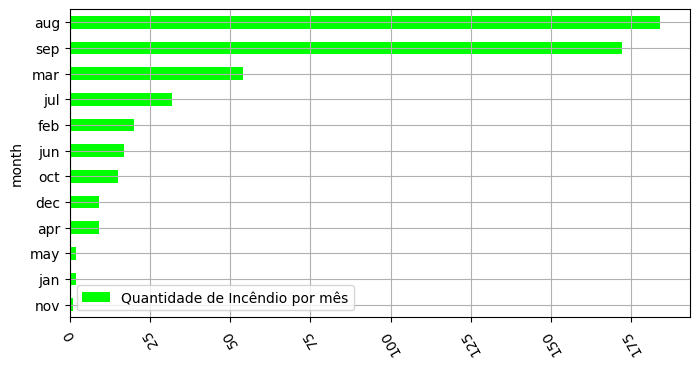

In [9]:
por_mes = ff['month'].value_counts().sort_values(ascending=[True])
por_mes.plot(kind='barh', label="Quantidade de Incêndio por mês" ,figsize=(8, 4), grid=True, color='lime', legend=True)
plt.xticks(rotation=120);

### 3 - Explique os seguintes métodos:
* `value_counts()`
* `sort_values()`
* `plot()`


---
O `value_counts()` conta quantas vezes cada valor diferente aparece na coluna, retornando uma Series com o valor como índice e a quantidade como conteúdo. Na coluna `month` ele mostrou que ago teve 184 ocorrências e set 172, sendo os meses com mais incêndios.

O `sort_values()` ordena os dados pelos valores. Com `ascending=True` ordena do menor para o maior e com `ascending=False` do maior para o menor. Aqui foi usado para deixar as barras do gráfico em ordem crescente de quantidade.

Já o `plot()` gera o gráfico a partir do DataFrame ou da Series usando o matplotlib. O parâmetro `kind` define o tipo do gráfico (barh, bar, line, pie, etc) e os outros parâmetros configuram tamanho (`figsize`), grade (`grid`), cor (`color`) e legenda (`legend`).


### 4 - Responda as seguintes perguntas:
1. O grafico de barras horizontais é adequado para esse tipo de dados? Justifique a resposta.

2. Quais melhorias você faria nesse gráfico? Justifique porque.


---
1. Sim, é adequado. O mês é uma variável categórica e o que está sendo mostrado é a contagem de ocorrências de cada categoria, que é justamente o que um gráfico de barras representa bem. A versão horizontal ainda ajuda porque são 12 categorias e os nomes dos meses ficam escritos na horizontal, sem precisar girar o texto, o que facilita a leitura e a comparação entre os meses.

2.
- Tirar o `plt.xticks(rotation=120)`. Girar os números do eixo x em 120 graus deixa os valores de cabeça para baixo e só atrapalha a leitura.
- Colocar título no gráfico e nome nos eixos ("Quantidade de incêndios" no x e "Mês" no y), porque hoje só existe a legenda e o leitor precisa deduzir o que cada eixo representa.
- Trocar a cor `lime` por uma cor mais frote, porque o verde limão tem pouco contraste com o fundo branco e cansa a vista.
- Ordem cronológica dos meses (jan a dez).
- Escrever o valor da contagem na ponta de cada barra, assim dá para saber o número exato sem precisar estimar pela grade.
- Traduzir as siglas dos meses para o português, já que o resto da análise está em português.


### Gerando um gráfico com os dados da umidade relativa média por mês



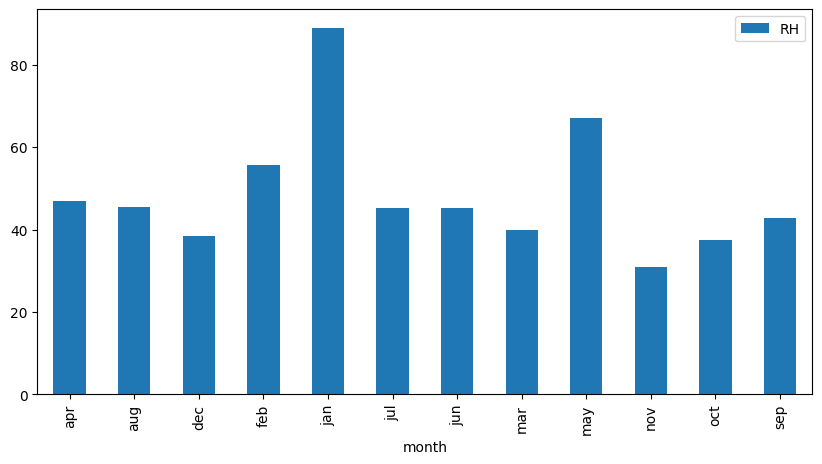

In [10]:
por_umidade = ff[['month','RH']].groupby('month').mean()
por_umidade.plot(kind='bar', figsize=(10, 5));

### 5 - Explique os seguintes métodos:
* `groupby()`
* `mean()`


---
`groupby()` Agrupa as linhas do DataFrame pelos valores de uma ou mais colunas, juntando num mesmo grupo todas as linhas que têm o mesmo valor. Sozinho ele apenas cria os grupos, é preciso uma função de agregação depois para gerar o resultado. Aqui ele agrupou todas as linhas pelo mês.

`mean()` Calcula a média aritmética dos valores. Aplicado depois do `groupby('month')`, ele calcula a média da umidade relativa dentro de cada mês separadamente, retornando um valor por mês em vez de um único valor do dataset inteiro.


### 6 - Responda as seguintes perguntas:
1. O grafico de barras verticais é adequado para esse tipo de dados? Justifique a resposta.

2. Quais melhorias você faria nesse gráfico? Justifique porque.


---
1. É adequado em parte. Como se trata de comparar um valor numérico (a média de RH) entre categorias (os meses), o gráfico de barras cumpre bem esse papel. Porém os meses formam uma sequência temporal, então um gráfico de linhas mostraria melhor a variação da umidade ao longo do ano. Além disso a média esconde a quantidade de registros de cada mês, por exemplo, jan tem apenas 2 registros e nov apenas 1, e mesmo assim aparecem com o mesmo peso visual de ago, que tem 184 registros, o que passa uma impressão errada de confiabilidade.

2. 
- Ordenar os meses na ordem do calendário, porque o `groupby()` ordena em ordem alfabética (abr, ago, dez, fev...) e isso quebra a leitura da sazonalidade.
- Colocar título e nome nos eixos, deixando claro que o eixo y é a umidade relativa média em porcentagem.
- Indicar a quantidade de registros de cada mês (no rótulo ou com barra de erro/desvio padrão), para deixar explícito que as médias de jan, mai e nov vêm de pouquíssimas amostras.
- Deixar os nomes dos meses na horizontal, já que são siglas curtas e não precisam ficar inclinadas.
- Considerar trocar por um gráfico de linha, que representa melhor a evolução da umidade ao longo do ano.


### 7 - Sugira mais dois gráficos de análises que poderiam ser feitas para esses dados. Não precisa colocar os gráficos, somente fazer as sugestões de análises a serem feitas.


---
Uma seria um gráfico de dispersão da temperatura contra a área queimada, com a temperatura no eixo x e a área no eixo y. A análise seria verificar se existe relação entre dias mais quentes e incêndios maiores. Como a coluna `area` tem muitos zeros e alguns valores extremos, daria para aplicar log na área ou filtrar somente os registros com área maior que zero para enxergar melhor a relação. A mesma ideia serve para a umidade relativa (RH) contra a área, onde a expectativa é de uma relação inversa. <br> 
A outra sugestão, seria um mapa de calor das coordenadas X e Y do parque, que contaria quantos incêndios ocorreram em cada posição da grade. A análise seria identificar quais regiões do parque Montesinho concentram mais ocorrências, o que ajudaria a direcionar a prevenção e a fiscalização para essas áreas. Uma variação seria somar a área queimada em vez de contar as ocorrências, para ver onde os incêndios foram mais destrutivos.
